In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path
import numpy as np


In [2]:


def find_project_root():
    current = Path.cwd()
    # Check if current directory has data/raw folder
    if (current / "data" / "raw").exists():
        return current
    # Check parent directory
    parent = current.parent
    if (parent / "data" / "raw").exists():
        return parent
    # Fall back to looking for .git
    for p in [current, *current.parents]:
        if (p / ".git").exists():
            return p
    return current

PROJECT_ROOT = find_project_root()

# Add src to path for imports
import sys
sys.path.insert(0, str(PROJECT_ROOT))

# Import reusable utilities
from src.data_processing import *
from src.statistics import *
from src.visualization import *
from src.data_cleaning import  * 

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "reports" / "figures"

appearances = pd.read_csv(DATA_RAW / "appearances.csv")
players = pd.read_csv(DATA_RAW / "players (1).csv")
games = pd.read_csv(DATA_RAW / "games.csv")
competitions = pd.read_csv(DATA_RAW / "competitions.csv")

In [3]:

# ============================================================
# CLEAN APPEARANCES DATA
# ============================================================

print_section("CLEANING APPEARANCES DATA")

print(f"Before cleaning: {appearances.shape[0]} rows, {appearances.shape[1]} columns")
print(f"Initial missing values:\n{appearances.isnull().sum()}\n")

appearances = remove_exact_duplicates(appearances)

# These columns are essential because they connect appearances to players/games/competitions.
appearance_critical_cols = [
    "appearance_id",
    "game_id",
    "player_id",
    "player_club_id",
    "competition_id"
]

appearances = drop_missing_critical_ids(appearances, appearance_critical_cols)

# These are match-event/count columns. Missing values here should not delete the row.
appearance_stat_cols = [
    "goals",
    "assists",
    "yellow_cards",
    "red_cards",
    "minutes_played"
]

appearances = fill_numeric_columns(appearances, appearance_stat_cols, fill_value=0)

# Make sure stat columns are clean integers where possible.
for col in appearance_stat_cols:
    if col in appearances.columns:
        appearances[col] = appearances[col].astype(int)

# Clean text columns without deleting rows.
appearance_text_cols = [
    "player_name",
    "competition_id"
]

appearances = clean_text_columns_keep_missing(appearances, appearance_text_cols)

# Convert date if present.
appearances = convert_date_columns(appearances, ["date"])

# Safety checks for GA per 90 later.
if {"goals", "assists"}.issubset(appearances.columns):
    appearances["goal_assists"] = appearances["goals"] + appearances["assists"]

if "minutes_played" in appearances.columns:
    appearances["minutes_played"] = pd.to_numeric(
        appearances["minutes_played"],
        errors="coerce"
    ).fillna(0)

quality_report(appearances, "Appearances")


# ============================================================
# CLEAN PLAYERS DATA
# ============================================================

print_section("CLEANING PLAYERS DATA")

print(f"Before cleaning: {players.shape[0]} rows, {players.shape[1]} columns")
print(f"Initial missing values:\n{players.isnull().sum()}\n")

players = remove_exact_duplicates(players)

# Only drop players if their identity is missing.
player_critical_cols = [
    "player_id",
    "name"
]

players = drop_missing_critical_ids(players, player_critical_cols)

# Fill categorical columns with Unknown.
player_categorical_cols = [
    "first_name",
    "last_name",
    "country_of_birth",
    "city_of_birth",
    "country_of_citizenship",
    "position",
    "sub_position",
    "foot",
    "agent_name",
    "current_club_name",
    "current_club_domestic_competition_id"
]

players = fill_text_columns(players, player_categorical_cols, fill_value="Unknown")

# Clean player name specifically.
if "name" in players.columns:
    players["name"] = (
        players["name"]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Convert dates but keep missing dates as NaT.
player_date_cols = [
    "date_of_birth",
    "contract_expiration_date"
]

players = convert_date_columns(players, player_date_cols)

# Numeric columns: keep missing values.
# Do NOT blindly fill market value or height with 0.
player_numeric_cols = [
    "height_in_cm",
    "market_value_in_eur",
    "highest_market_value_in_eur",
    "last_season",
    "current_club_id"
]

players = convert_numeric_columns_keep_missing(players, player_numeric_cols)

quality_report(players, "Players")


# ============================================================
# CLEAN GAMES DATA
# ============================================================

print_section("CLEANING GAMES DATA")

print(f"Before cleaning: {games.shape[0]} rows, {games.shape[1]} columns")
print(f"Initial missing values:\n{games.isnull().sum()}\n")

games = remove_exact_duplicates(games)

# These are essential for joining games with appearances and competitions.
game_critical_cols = [
    "game_id",
    "competition_id",
    "home_club_id",
    "away_club_id"
]

games = drop_missing_critical_ids(games, game_critical_cols)

# Convert date.
games = convert_date_columns(games, ["date"])

# Scores should be numeric, but do not automatically fill missing scores with 0.
# Missing score can mean incomplete/future/invalid game.
game_score_cols = [
    "home_club_goals",
    "away_club_goals",
    "home_club_position",
    "away_club_position",
    "attendance",
    "season"
]

games = convert_numeric_columns_keep_missing(games, game_score_cols)

# Text columns.
game_text_cols = [
    "round",
    "home_club_manager_name",
    "away_club_manager_name",
    "stadium",
    "referee",
    "url",
    "home_club_name",
    "away_club_name",
    "aggregate",
    "competition_type",
    "competition_id"
]

games = fill_text_columns(games, game_text_cols, fill_value="Unknown")

quality_report(games, "Games")


# ============================================================
# CLEAN COMPETITIONS DATA
# ============================================================

print_section("CLEANING COMPETITIONS DATA")

print(f"Before cleaning: {competitions.shape[0]} rows, {competitions.shape[1]} columns")
print(f"Initial missing values:\n{competitions.isnull().sum()}\n")

competitions = remove_exact_duplicates(competitions)

# Competition identity is essential.
competition_critical_cols = [
    "competition_id",
    "name"
]

competitions = drop_missing_critical_ids(competitions, competition_critical_cols)

# Text columns.
competition_text_cols = [
    "competition_id",
    "competition_code",
    "name",
    "sub_type",
    "type",
    "country_name",
    "domestic_league_code",
    "confederation",
    "url"
]

competitions = fill_text_columns(competitions, competition_text_cols, fill_value="Unknown")

# Numeric columns.
competition_numeric_cols = [
    "country_id"
]

competitions = convert_numeric_columns_keep_missing(competitions, competition_numeric_cols)

quality_report(competitions, "Competitions")


# ============================================================
# FINAL SAFETY CHECKS FOR GA PER 90
# ============================================================

print_section("FINAL SAFETY CHECKS")

required_ga_cols = [
    "player_id",
    "goals",
    "assists",
    "minutes_played"
]

missing_ga_cols = [col for col in required_ga_cols if col not in appearances.columns]

if missing_ga_cols:
    print(f"Warning: missing columns needed for GA per 90: {missing_ga_cols}")
else:
    print("Columns needed for GA per 90 are present.")

    appearances["goals"] = pd.to_numeric(appearances["goals"], errors="coerce").fillna(0)
    appearances["assists"] = pd.to_numeric(appearances["assists"], errors="coerce").fillna(0)
    appearances["minutes_played"] = pd.to_numeric(appearances["minutes_played"], errors="coerce").fillna(0)

    appearances["goal_assists"] = appearances["goals"] + appearances["assists"]

    print("\nGA columns data types:")
    print(appearances[["goals", "assists", "goal_assists", "minutes_played"]].dtypes)

    print("\nRows with 0 minutes:")
    print((appearances["minutes_played"] == 0).sum())

print("\n" + "=" * 60)
print("✓ ALL DATASETS CLEANED SAFELY")
print("=" * 60)


CLEANING APPEARANCES DATA
Before cleaning: 1889406 rows, 13 columns
Initial missing values:
appearance_id             0
game_id                   0
player_id                 0
player_club_id            0
player_current_club_id    0
date                      0
player_name               2
competition_id            0
yellow_cards              0
red_cards                 0
goals                     0
assists                   0
minutes_played            0
dtype: int64

Removed duplicates: 0
Dropped rows missing critical IDs: 0

Appearances shape: 1889406 rows, 14 columns

Missing values:
player_name               2
appearance_id             0
player_id                 0
player_club_id            0
player_current_club_id    0
game_id                   0
date                      0
competition_id            0
yellow_cards              0
red_cards                 0
goals                     0
assists                   0
minutes_played            0
goal_assists              0
dtype: int64

Da

## Analysis 1: Best Single Season Performance
This section analyzes player rarity based on their **single best season**. It identifies each attacker's peak performance year and calculates how statistically rare that achievement was compared to all other attacking seasons in the dataset (2005-2026).


Merged dataframe shape: (1885175, 19)
    appearance_id  game_id  player_id  player_club_id  player_current_club_id  \
0   2231978_38004  2231978      38004             853                     235   
1   2233748_79232  2233748      79232            8841                    2698   
2   2234413_42792  2234413      42792            6251                     465   
3   2234418_73333  2234418      73333            1274                      76   
4  2234421_122011  2234421     122011             195                    3008   

        date       player_name competition_id_x  yellow_cards  red_cards  \
0 2012-07-03  Aurélien Joachim              CLQ             0          0   
1 2012-07-05    Ruslan Abyshov              ELQ             0          0   
2 2012-07-05       Sander Puri              ELQ             0          0   
3 2012-07-05   Vegar Hedenstad              ELQ             0          0   
4 2012-07-05  Markus Henriksen              ELQ             0          0   

   goals  assists

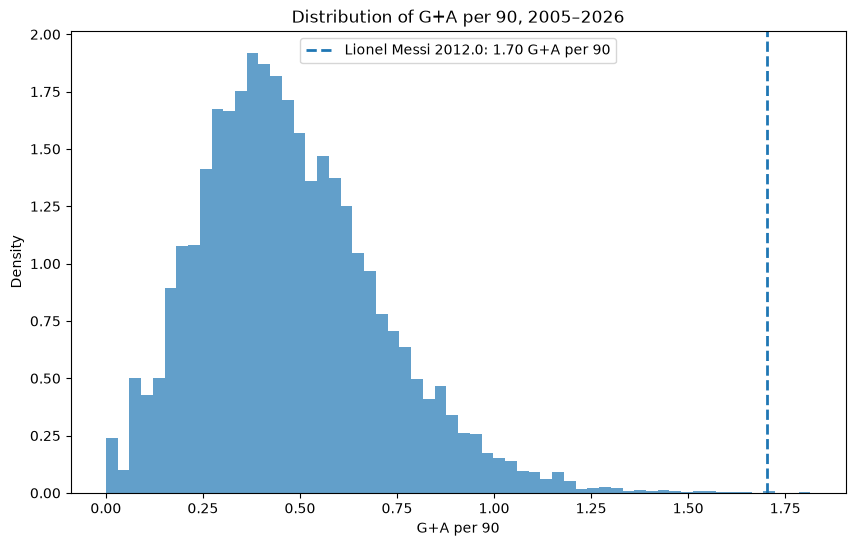

No data found for: Neymar
✓ Saved figure to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\reports\figures\01_best_season_distribution.png

================ PLAYER COMPARISON ================
               Player  Best Season  G+A per 90   z-score  \
0        Lionel Messi       2012.0    1.702703  5.246815   
1   Cristiano Ronaldo       2014.0    1.628959  4.931451   
5         Luis Suárez       2015.0    1.567352  4.667987   
2      Erling Haaland       2019.0    1.516245  4.449429   
3       Kylian Mbappé       2018.0    1.514851  4.443468   
4  Robert Lewandowski       2020.0    1.513721  4.438633   

   Empirical Probability Empirical Rarity  
0               0.000221       1 in 4,532  
1               0.000515       1 in 1,942  
5               0.000736       1 in 1,360  
2               0.001030         1 in 971  
3               0.001103         1 in 906  
4               0.001177         1 in 850  


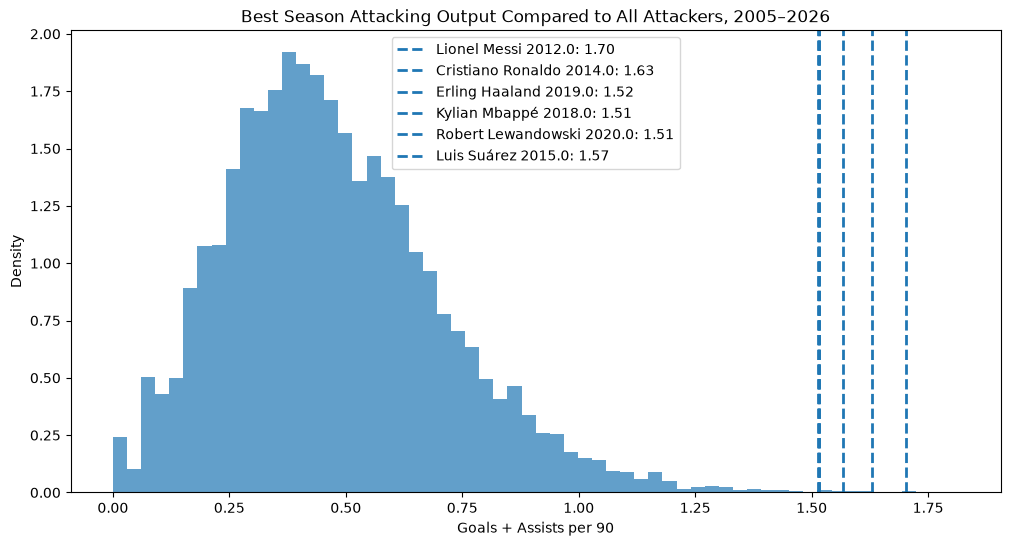

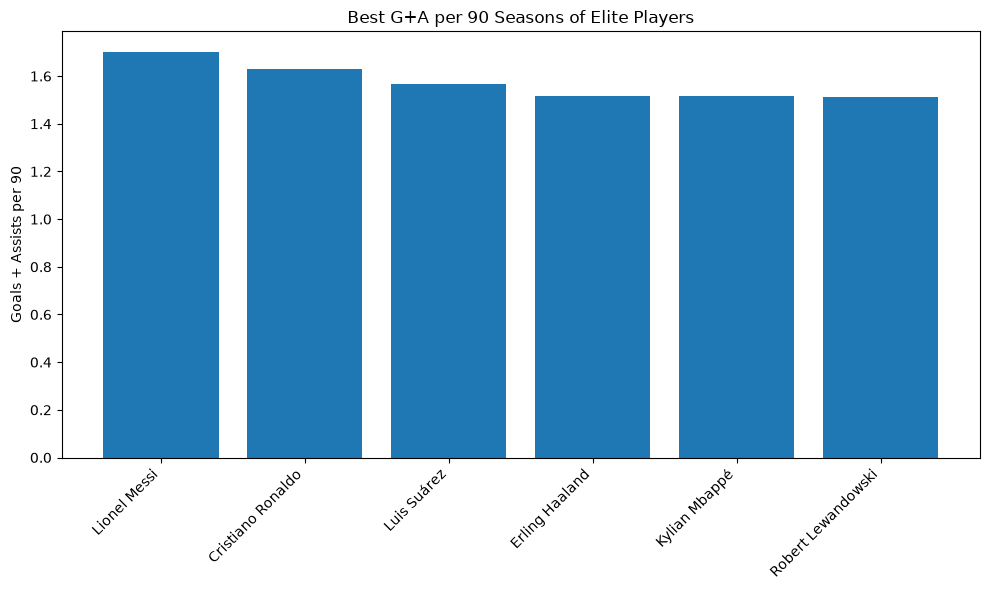

In [4]:

# ============================================================
# 1. MERGE AND PREPARE DATA
# ============================================================

df = merge_appearances_with_games(appearances, games)
df = merge_with_players(df, players)
df = filter_seasons(df, min_season=2005, max_season=2026)
df = create_ga_column(df)

print("\nMerged dataframe shape:", df.shape)
print(df.head())

print("\nSeason range:")
print(df["season"].min(), "to", df["season"].max())

print("\nSample after creating GA:")
print(df[["name", "season", "goals", "assists", "GA", "minutes_played"]].head())


# ============================================================
# 2. AGGREGATE AND FILTER DATA
# ============================================================

season_stats = aggregate_by_season(df)
attackers = filter_attackers(season_stats)

print("\nSeason-level dataset:")
print(season_stats.head())

print("\nSeason stats shape:", season_stats.shape)
print("\nAttackers dataset shape:", attackers.shape)

print("\nAttacker positions found:")
print(attackers["position"].value_counts().head(20))

# ============================================================
# 3. FIND ONE PLAYER'S BEST SEASON
# ============================================================

player_name = "Messi"

player_rows = find_player_seasons(attackers, player_name)

print(f"\nBest seasons found for {player_name}:")
print(player_rows[["name", "season", "position", "minutes_played", "goals", "assists", "GA", "GA_per90"]].head(10))


# ============================================================
# 4. CALCULATE AND VISUALIZE RARITY FOR ONE PLAYER
# ============================================================

if player_rows.empty:
    print(f"\nNo player found matching: {player_name}")
else:
    player_value = player_rows["GA_per90"].iloc[0]
    player_season = player_rows["season"].iloc[0]
    player_full_name = player_rows["name"].iloc[0]

    # Calculate rarity metrics
    rarity_metrics = calculate_rarity_metrics(player_value, attackers["GA_per90"])
    
    # Print report
    player_info = {
        "Player": player_full_name,
        "Best season": player_season,
        "G+A per 90": player_value
    }
    print_rarity_report(player_info, rarity_metrics, "Single Season")
    
    # Visualize
    plot_distribution_with_player(
        attackers["GA_per90"], 
        player_value, 
        player_full_name, 
        season=player_season
    )


# ============================================================
# 5. COMPARE MULTIPLE ELITE PLAYERS
# ============================================================

players_to_compare = [
    "Messi",
    "Cristiano Ronaldo",
    "Haaland",
    "Mbapp",
    "Lewandowski",
    "Neymar",
    "Suárez"
]

plt.figure(figsize=(12, 6))

plt.hist(
    attackers["GA_per90"],
    bins=60,
    density=True,
    alpha=0.7
)

comparison_results = []

for p in players_to_compare:
    rows = attackers[
        attackers["name"].str.contains(p, case=False, na=False)
    ].sort_values("GA_per90", ascending=False)

    if not rows.empty:
        best_value = rows["GA_per90"].iloc[0]
        best_season = rows["season"].iloc[0]
        full_name = rows["name"].iloc[0]

        z_score = (best_value - attackers["GA_per90"].mean()) / attackers["GA_per90"].std()
        empirical_probability = (attackers["GA_per90"] >= best_value).mean()

        comparison_results.append({
            "Player": full_name,
            "Best Season": best_season,
            "G+A per 90": best_value,
            "z-score": z_score,
            "Empirical Probability": empirical_probability,
            "Empirical Rarity": f"1 in {1 / empirical_probability:,.0f}" if empirical_probability > 0 else "Undefined"
        })

        plt.axvline(
            best_value,
            linestyle="--",
            linewidth=2,
            label=f"{full_name} {best_season}: {best_value:.2f}"
        )
    else:
        print(f"No data found for: {p}")

plt.xlabel("Goals + Assists per 90")
plt.ylabel("Density")
plt.title("Best Season Attacking Output Compared to All Attackers, 2005–2026")
plt.legend()
    
# Save figure
from src.visualization import *
save_figure("01_best_season_distribution.png", FIGURES)
# 6. DISPLAY COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(comparison_results)

print("\n================ PLAYER COMPARISON ================")

print(comparison_df.sort_values("G+A per 90", ascending=False))


# ============================================================
# 7. OPTIONAL: BAR CHART OF ELITE PLAYERS
# ============================================================

if not comparison_df.empty:
    comparison_df = comparison_df.sort_values("G+A per 90", ascending=False)

    plt.figure(figsize=(10, 6))

    plt.bar(
        comparison_df["Player"],
        comparison_df["G+A per 90"]
    )


    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Goals + Assists per 90")
    plt.title("Best G+A per 90 Seasons of Elite Players")
    plt.tight_layout()
    plt.show()

## Analysis 2: Career Performance (All Available Seasons Combined)
This section analyzes player rarity based on **career-long aggregate statistics**. It combines all seasons for each player to calculate their career G+A per 90 minutes, showing how their sustained excellence compares to other attackers across their entire active period in the dataset.


Career-level dataset:
   player_id                name    position  goals  assists  GA  \
0         10      Miroslav Klose      Attack     48       25  73   
1         26  Roman Weidenfeller  Goalkeeper      0        0   0   
2         65    Dimitar Berbatov      Attack     38       13  51   
5        109                Dedê    Defender      1        2   3   
7        132       Tomas Rosicky    Midfield      9        4  13   

   minutes_played  appearances  first_season  last_season  active_seasons  \
0            8808          136        2012.0       2015.0               4   
1           13508          152        2012.0       2017.0               6   
2            8788          122        2012.0       2015.0               4   
5            3584           41        2012.0       2013.0               2   
7            3987           77        2012.0       2015.0               4   

   ninety_minutes  GA_per90  
0       97.866667  0.745913  
1      150.088889  0.000000  
2       97.6444

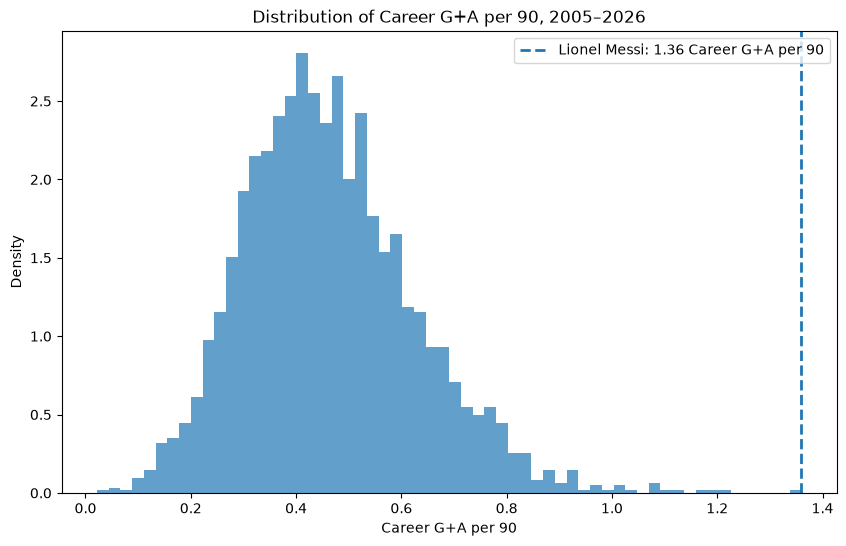

No data found for: Neymar


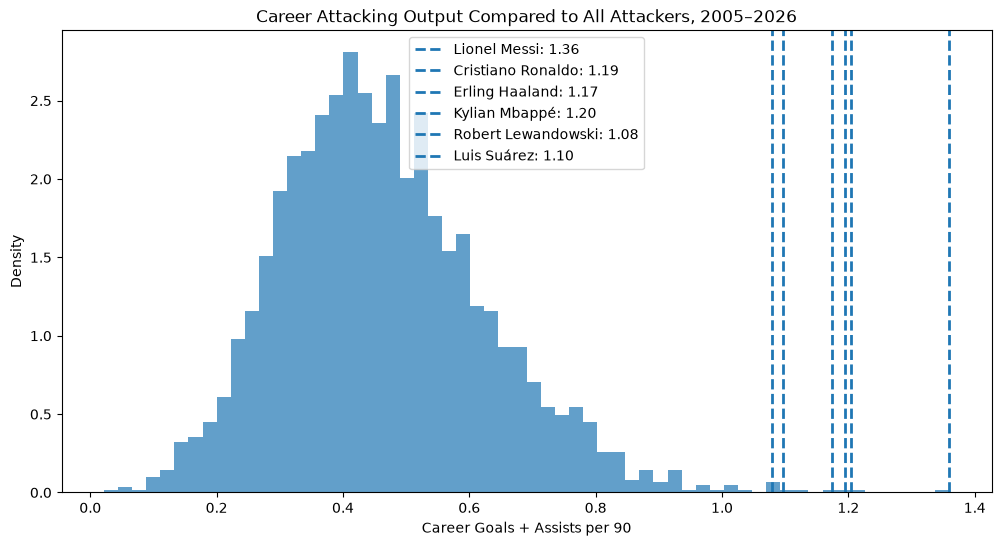


================ PLAYER COMPARISON ================
               Player  First Season  Last Season  Active Seasons  Appearances  \
0        Lionel Messi        2012.0       2025.0              12          526   
3       Kylian Mbappé        2015.0       2025.0              11          426   
1   Cristiano Ronaldo        2012.0       2022.0              11          482   
2      Erling Haaland        2019.0       2025.0               7          290   
5         Luis Suárez        2012.0       2021.0              10          445   
4  Robert Lewandowski        2012.0       2025.0              14          665   

   Minutes  Goals  Assists  G+A  Career G+A per 90   z-score  \
0    44740    452      224  676           1.359857  5.514800   
3    32736    326      112  438           1.204179  4.557373   
1    41150    432      114  546           1.194168  4.495804   
2    23456    255       51  306           1.174113  4.372468   
5    35950    289      149  438           1.096523  3.89528

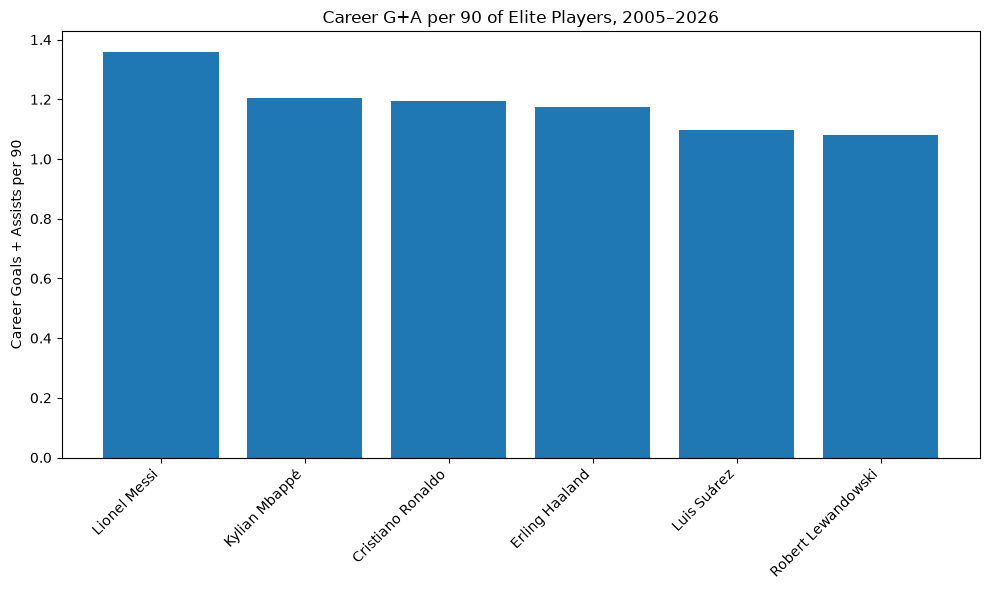


================ TOP 20 CAREER G+A PER 90 ================
                      name position  first_season  last_season  \
2262          Lionel Messi   Attack        2012.0       2025.0   
16662        Kylian Mbappé   Attack        2015.0       2025.0   
730      Cristiano Ronaldo   Attack        2012.0       2022.0   
18979       Erling Haaland   Attack        2019.0       2025.0   
192     Zlatan Ibrahimović   Attack        2012.0       2022.0   
3638           Luis Suárez   Attack        2012.0       2021.0   
26799           Franculino   Attack        2023.0       2025.0   
2141         Sergio Agüero   Attack        2012.0       2020.0   
3144    Robert Lewandowski   Attack        2012.0       2025.0   
16021      Viktor Gyökeres   Attack        2018.0       2025.0   
21827       Lassina Traoré   Attack        2018.0       2025.0   
20         Claudio Pizarro   Attack        2012.0       2019.0   
8913            Harry Kane   Attack        2012.0       2025.0   
4154            

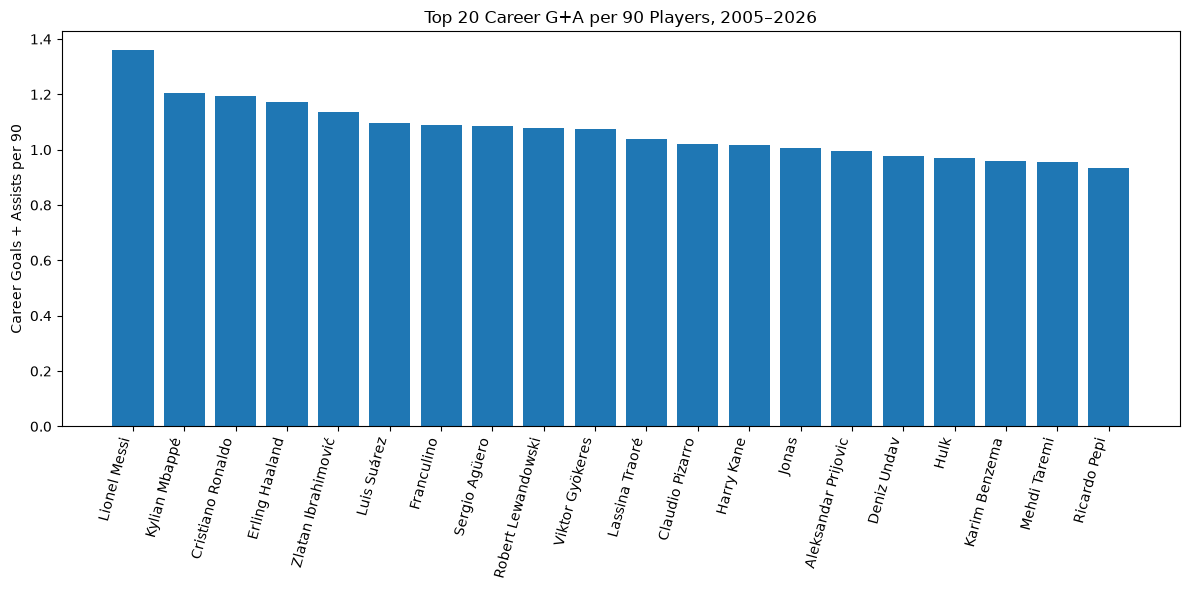

In [5]:

# ============================================================
# 1. AGGREGATE BY PLAYER ACROSS ALL ACTIVE YEARS
# ============================================================

career_stats = aggregate_by_career(df)
attackers = filter_attackers(career_stats)

print("\nCareer-level dataset:")
print(career_stats.head())

print("\nCareer stats shape:", career_stats.shape)
print("\nAttackers dataset shape:", attackers.shape)

print("\nAttacker positions found:")
print(attackers["position"].value_counts().head(20))


# ============================================================
# 2. FIND ONE PLAYER'S FULL ACTIVE-YEARS RECORD AND CALCULATE RARITY
# ============================================================

player_name = "Messi"

player_rows = find_player_seasons(attackers, player_name)

print(f"\nCareer records found for {player_name}:")
print(
    player_rows[
        [
            "name",
            "position",
            "first_season",
            "last_season",
            "active_seasons",
            "appearances",
            "minutes_played",
            "goals",
            "assists",
            "GA",
            "GA_per90"
        ]
    ]
)


# ============================================================
# 9. CALCULATE CAREER RARITY FOR THAT PLAYER
# ============================================================

if player_rows.empty:
    print(f"\nNo player found matching: {player_name}")
else:
    player_value = player_rows["GA_per90"].iloc[0]
    player_full_name = player_rows["name"].iloc[0]
    first_season = player_rows["first_season"].iloc[0]
    last_season = player_rows["last_season"].iloc[0]
    active_seasons = player_rows["active_seasons"].iloc[0]

    # Calculate rarity metrics
    rarity_metrics = calculate_rarity_metrics(player_value, attackers["GA_per90"])
    
    # Print report
    player_info = {
        "Player": player_full_name,
        "Period": f"{int(first_season)} to {int(last_season)}",
        "Active seasons": int(active_seasons),
        "Career G+A per 90": player_value
    }
    print_rarity_report(player_info, rarity_metrics, "Career")
    
    # Visualize
    plot_distribution_with_player(
        attackers["GA_per90"], 
        player_value, 
        player_full_name, 
        metric_name="Career G+A per 90"
    )


# ============================================================
# 3. COMPARE MULTIPLE PLAYERS BY FULL ACTIVE-YEARS RECORD
# ============================================================

players_to_compare = [
    "Messi",
    "Cristiano Ronaldo",
    "Haaland",
    "Mbapp",
    "Lewandowski",
    "Neymar",
    "Suárez"
]

plt.figure(figsize=(12, 6))

plt.hist(
    attackers["GA_per90"],
    bins=60,
    density=True,
    alpha=0.7
)

comparison_results = []

for p in players_to_compare:
    rows = attackers[
        attackers["name"].str.contains(p, case=False, na=False)
    ].sort_values("GA_per90", ascending=False)

    if not rows.empty:
        value = rows["GA_per90"].iloc[0]
        full_name = rows["name"].iloc[0]
        first_season = rows["first_season"].iloc[0]
        last_season = rows["last_season"].iloc[0]
        active_seasons = rows["active_seasons"].iloc[0]

        z_score = (value - attackers["GA_per90"].mean()) / attackers["GA_per90"].std()
        empirical_probability = (attackers["GA_per90"] >= value).mean()

        comparison_results.append({
            "Player": full_name,
            "First Season": first_season,
            "Last Season": last_season,
            "Active Seasons": active_seasons,
            "Appearances": rows["appearances"].iloc[0],
            "Minutes": rows["minutes_played"].iloc[0],
            "Goals": rows["goals"].iloc[0],
            "Assists": rows["assists"].iloc[0],
            "G+A": rows["GA"].iloc[0],
            "Career G+A per 90": value,
            "z-score": z_score,
            "Empirical Probability": empirical_probability,
            "Empirical Rarity": f"1 in {1 / empirical_probability:,.0f}" if empirical_probability > 0 else "Undefined"
        })

        plt.axvline(
            value,
            linestyle="--",
            linewidth=2,
            label=f"{full_name}: {value:.2f}"
        )
    else:
        print(f"No data found for: {p}")

plt.xlabel("Career Goals + Assists per 90")
plt.ylabel("Density")
plt.title("Career Attacking Output Compared to All Attackers, 2005–2026")
plt.legend()
plt.show()


# ============================================================
# 12. DISPLAY COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(comparison_results)

print("\n================ PLAYER COMPARISON ================")
print(comparison_df.sort_values("Career G+A per 90", ascending=False))


# ============================================================
# 13. BAR CHART OF ELITE PLAYERS
# ============================================================

if not comparison_df.empty:
    comparison_df = comparison_df.sort_values("Career G+A per 90", ascending=False)

    plt.figure(figsize=(10, 6))

    plt.bar(
        comparison_df["Player"],
        comparison_df["Career G+A per 90"]
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Career Goals + Assists per 90")
    plt.title("Career G+A per 90 of Elite Players, 2005–2026")
    plt.tight_layout()
    plt.show()


# ============================================================
# 14. TOP 20 CAREER G+A PER 90 PLAYERS
# ============================================================

top_20 = attackers.sort_values("GA_per90", ascending=False).head(20)

print("\n================ TOP 20 CAREER G+A PER 90 ================")
print(
    top_20[
        [
            "name",
            "position",
            "first_season",
            "last_season",
            "active_seasons",
            "appearances",
            "minutes_played",
            "goals",
            "assists",
            "GA",
            "GA_per90"
        ]
    ]
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_20["name"],
    top_20["GA_per90"]
)

plt.xticks(rotation=75, ha="right")
plt.ylabel("Career Goals + Assists per 90")
plt.title("Top 20 Career G+A per 90 Players, 2005–2026")
plt.tight_layout()
plt.show()

## Save Processed Datasets
Save all cleaned and processed datasets to preserve raw data integrity.

In [6]:
# ============================================================
# SAVE ALL PROCESSED DATASETS
# ============================================================

print("\n================ SAVING PROCESSED DATA ================\n")

# Save raw data with minimal processing (filtering seasons only)
save_processed_data(appearances, DATA_PROCESSED / "appearances_cleaned.csv")
save_processed_data(players, DATA_PROCESSED / "players_cleaned.csv")
save_processed_data(games, DATA_PROCESSED / "games_cleaned.csv")
save_processed_data(competitions, DATA_PROCESSED / "competitions_cleaned.csv")

# Save merged and aggregated data
save_processed_data(df, DATA_PROCESSED / "merged_data_cleaned.csv")
save_processed_data(season_stats, DATA_PROCESSED / "season_stats_cleaned.csv")
save_processed_data(career_stats, DATA_PROCESSED / "career_stats_cleaned.csv")

print("\n✓ All processed datasets saved to data/processed/")
print(f"  - appearances_cleaned.csv")
print(f"  - players_cleaned.csv")
print(f"  - games_cleaned.csv")
print(f"  - competitions_cleaned.csv")
print(f"  - merged_data_cleaned.csv")
print(f"  - season_stats_cleaned.csv")
print(f"  - career_stats_cleaned.csv")


================ SAVING PROCESSED DATA ================

✓ Saved processed data to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\data\processed\appearances_cleaned.csv
✓ Saved processed data to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\data\processed\players_cleaned.csv
✓ Saved processed data to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\data\processed\games_cleaned.csv
✓ Saved processed data to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\data\processed\competitions_cleaned.csv
✓ Saved processed data to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\data\processed\merged_data_cleaned.csv
✓ Saved processed data to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\data\processed\season_stats_cleaned.csv
✓ Saved processed data to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\data\processed\career_stats_cleaned.csv

✓ All processed datasets saved to data/proces

In [7]:
# ============================================================
# SAVE ALL VISUALIZATIONS
# ============================================================

import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import save_figure

print("\n================ SAVING VISUALIZATIONS ================\n")

# Get best season attackers dataframe (recompute from season_stats)
best_season_attackers = season_stats[
    season_stats["position"].str.contains(
        "Attack|Forward|Centre-Forward|Winger|Second Striker|Left Winger|Right Winger",
        case=False,
        na=False
    )
]

# Figure 1: Best Season Distribution
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.hist(best_season_attackers["GA_per90"], bins=60, density=True, alpha=0.7)
player_rows_best = best_season_attackers[best_season_attackers["name"].str.contains("Messi", case=False, na=False)].sort_values("GA_per90", ascending=False)
if not player_rows_best.empty:
    player_value_best = player_rows_best["GA_per90"].iloc[0]
    player_season_best = player_rows_best["season"].iloc[0]
    ax1.axvline(player_value_best, linestyle="--", linewidth=2, label=f"Messi {int(player_season_best)}: {player_value_best:.2f} G+A/90")
ax1.set_xlabel("Goals + Assists per 90")
ax1.set_ylabel("Density")
ax1.set_title("Best Single Season Performance Distribution - All Attackers (2005-2026)")
ax1.legend()
save_figure("01_best_season_distribution.png", FIGURES, dpi=300)
plt.close(fig1)
print("✓ Figure 1 saved")

# Figure 2: Season Comparison Distribution
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.hist(best_season_attackers["GA_per90"], bins=60, density=True, alpha=0.7)

players_compare = ["Messi", "Cristiano Ronaldo", "Haaland", "Lewandowski", "Suárez"]
colors = ['red', 'blue', 'green', 'purple', 'orange']
for p, color in zip(players_compare, colors):
    rows = best_season_attackers[best_season_attackers["name"].str.contains(p, case=False, na=False)].sort_values("GA_per90", ascending=False)
    if not rows.empty:
        best_value = rows["GA_per90"].iloc[0]
        best_season = rows["season"].iloc[0]
        full_name = rows["name"].iloc[0]
        ax2.axvline(best_value, linestyle="--", linewidth=2, label=f"{full_name} {int(best_season)}: {best_value:.2f}", color=color)

ax2.set_xlabel("Goals + Assists per 90")
ax2.set_ylabel("Density")
ax2.set_title("Elite Players - Best Season Performance Comparison")
ax2.legend()
save_figure("02_elite_players_season_comparison.png", FIGURES, dpi=300)
plt.close(fig2)
print("✓ Figure 2 saved")

# Figure 3: Elite Players Bar Chart - create manually from top performers
fig3, ax3 = plt.subplots(figsize=(10, 6))
elite_players_data = best_season_attackers[best_season_attackers["name"].str.contains("Messi|Cristiano Ronaldo|Haaland|Lewandowski|Suárez", case=False, na=False)]
elite_top = elite_players_data.drop_duplicates(subset=['name']).nlargest(6, 'GA_per90')[['name', 'GA_per90']]
ax3.bar(elite_top["name"], elite_top["GA_per90"], color='steelblue')
ax3.set_xlabel("Player")
ax3.set_ylabel("Goals + Assists per 90")
ax3.set_title("Best G+A per 90 Seasons of Elite Attackers")
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
fig3.tight_layout()
save_figure("03_elite_players_bar_chart.png", FIGURES, dpi=300)
plt.close(fig3)
print("✓ Figure 3 saved")

# Figure 4: Career Distribution
career_attackers = career_stats[
    career_stats["position"].str.contains(
        "Attack|Forward|Centre-Forward|Winger|Second Striker|Left Winger|Right Winger",
        case=False,
        na=False
    )
]
fig4, ax4 = plt.subplots(figsize=(10, 6))
ax4.hist(career_attackers["GA_per90"], bins=60, density=True, alpha=0.7)
career_messi = career_attackers[career_attackers["name"].str.contains("Messi", case=False, na=False)]
if not career_messi.empty:
    career_value = career_messi["GA_per90"].iloc[0]
    ax4.axvline(career_value, linestyle="--", linewidth=2, label=f"Messi Career: {career_value:.2f} G+A/90")
ax4.set_xlabel("Career Goals + Assists per 90")
ax4.set_ylabel("Density")
ax4.set_title("Career Performance Distribution - All Attackers (2005-2026)")
ax4.legend()
save_figure("04_career_distribution.png", FIGURES, dpi=300)
plt.close(fig4)
print("✓ Figure 4 saved")

# Figure 5: Top 20 Career Players
fig5, ax5 = plt.subplots(figsize=(12, 6))
top_20_career = career_attackers.sort_values("GA_per90", ascending=False).head(20)
ax5.barh(top_20_career["name"], top_20_career["GA_per90"], color='seagreen')
ax5.set_xlabel("Career Goals + Assists per 90")
ax5.set_title("Top 20 Players by Career G+A per 90 (Minimum 3000 minutes)")
fig5.tight_layout()
save_figure("05_top_20_career_players.png", FIGURES, dpi=300)
plt.close(fig5)
print("✓ Figure 5 saved")

print("\n✓ All visualizations successfully saved to reports/figures/")


================ SAVING VISUALIZATIONS ================

✓ Saved figure to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\reports\figures\01_best_season_distribution.png
✓ Figure 1 saved
✓ Saved figure to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\reports\figures\02_elite_players_season_comparison.png
✓ Figure 2 saved
✓ Saved figure to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\reports\figures\03_elite_players_bar_chart.png
✓ Figure 3 saved
✓ Saved figure to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\reports\figures\04_career_distribution.png
✓ Figure 4 saved
✓ Saved figure to: c:\Users\pc\Documents\GitHub\PROJECTS\FOOTBALL RARITY ANALYSIS\reports\figures\05_top_20_career_players.png
✓ Figure 5 saved

✓ All visualizations successfully saved to reports/figures/
